# 04 — Baseline Policy Simulation
**Phase 4: Mean vs Newsvendor — Age-Structured Monte Carlo**

**System:** 3-day shelf life, FIFO, stochastic lead time (P(L=1)=0.8), lost sales

**Economics:** price=$4.00, cost=$1.50, salvage=$0 → cu=$2.50, co=$1.50, critical fractile=0.625

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
TBL_DIR  = "../outputs/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

SELL_PRICE, UNIT_COST, SALVAGE = 4.0, 1.50, 0.0
P_LEAD_1 = 0.8
N_RUNS, SEED = 1000, 42

## 1. Load demand model and compute targets

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_daily_demand_cleaned.csv"), parse_dates=["Date"])
D_hist = df["Daily_Demand"].astype(int).to_numpy()
T = len(D_hist)

P_df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"))
demand_values = P_df["Demand_D"].to_numpy()
demand_probs  = P_df["P_smoothed"].to_numpy()

cu = max(0.0, SELL_PRICE - UNIT_COST)
co = max(1e-9, UNIT_COST - SALVAGE)
S_mean = int(round(D_hist.mean()))

crit_frac = cu / (cu + co)
cdf = np.cumsum(demand_probs)
S_nv = int(demand_values[np.searchsorted(cdf, crit_frac, side="left")])

print(f"T = {T} days | cu = ${cu:.2f} | co = ${co:.2f} | Critical fractile = {crit_frac:.3f}")
print(f"S_mean = {S_mean} | S_newsvendor = {S_nv}")

T = 364 days | cu = $2.50 | co = $1.50 | Critical fractile = 0.625
S_mean = 9 | S_newsvendor = 10


## 2. Age-structured simulator

In [3]:
def simulate_policy(order_up_to_S, T, demand_values, demand_probs, rng):
    E0 = E1 = E2 = 0
    A1 = A2 = 0
    total_unmet = total_waste = total_onhand_end = total_demand = 0

    for _ in range(T):
        # 1. Receive arrivals
        arriving = A1; A1, A2 = A2, 0; E2 += arriving
        # 2. Order decision
        inv_pos = (E0+E1+E2) + (A1+A2)
        q = max(0, order_up_to_S - inv_pos)
        if q > 0:
            L = 1 if rng.random() < P_LEAD_1 else 2
            if L == 1: A1 += q
            else: A2 += q
        # 3. Demand + FIFO
        D = int(rng.choice(demand_values, p=demand_probs))
        total_demand += D
        rem = D
        x = min(E0,rem); E0-=x; rem-=x
        x = min(E1,rem); E1-=x; rem-=x
        x = min(E2,rem); E2-=x; rem-=x
        total_unmet += rem
        # 4. Expiry
        total_waste += E0; E0 = 0
        # 5. Aging
        E0, E1, E2 = E1, E2, 0
        total_onhand_end += (E0+E1+E2)

    return {"S": order_up_to_S, "total_demand": total_demand, "total_unmet": total_unmet,
            "total_waste": total_waste, "avg_unmet_per_day": total_unmet/T,
            "avg_waste_per_day": total_waste/T, "avg_onhand_end": total_onhand_end/T,
            "fill_rate": 1.0 - total_unmet/max(1,total_demand)}

def run_many(S, seed):
    rng = np.random.default_rng(seed)
    return pd.DataFrame([simulate_policy(S, T, demand_values, demand_probs, rng) for _ in range(N_RUNS)])

## 3. Run simulations

In [4]:
print(f"Running {N_RUNS} MC runs for mean policy (S={S_mean})...")
res_mean = run_many(S_mean, SEED)

print(f"Running {N_RUNS} MC runs for newsvendor policy (S={S_nv})...")
res_nv = run_many(S_nv, SEED + 999)

Running 1000 MC runs for mean policy (S=9)...
Running 1000 MC runs for newsvendor policy (S=10)...


## 4. Results comparison

In [5]:
comparison = pd.DataFrame({
    "Mean_policy": res_mean.mean(numeric_only=True),
    "Newsvendor_policy": res_nv.mean(numeric_only=True),
})
comparison["Difference"] = comparison["Newsvendor_policy"] - comparison["Mean_policy"]
print(comparison)

comparison.to_csv(os.path.join(TBL_DIR, "baseline_comparison.csv"))

pcts = pd.DataFrame({
    "Mean_5th": res_mean.quantile(0.05), "Mean_50th": res_mean.quantile(0.50),
    "Mean_95th": res_mean.quantile(0.95), "NV_5th": res_nv.quantile(0.05),
    "NV_50th": res_nv.quantile(0.50), "NV_95th": res_nv.quantile(0.95),
})
pcts.to_csv(os.path.join(TBL_DIR, "baseline_percentiles.csv"))

print(f"\nMean policy fill rate:      {res_mean['fill_rate'].mean():.1%}")
print(f"Newsvendor policy fill rate: {res_nv['fill_rate'].mean():.1%}")

                   Mean_policy  Newsvendor_policy  Difference
S                     9.000000          10.000000    1.000000
total_demand       3344.081000        3352.638000    8.557000
total_unmet        1998.218000        1876.408000 -121.810000
total_waste           3.883000           5.501000    1.618000
avg_unmet_per_day     5.489610           5.154967   -0.334643
avg_waste_per_day     0.010668           0.015113    0.004445
avg_onhand_end        0.828574           1.023654    0.195080
fill_rate             0.402796           0.440719    0.037923

Mean policy fill rate:      40.3%
Newsvendor policy fill rate: 44.1%


## 5. Visualization

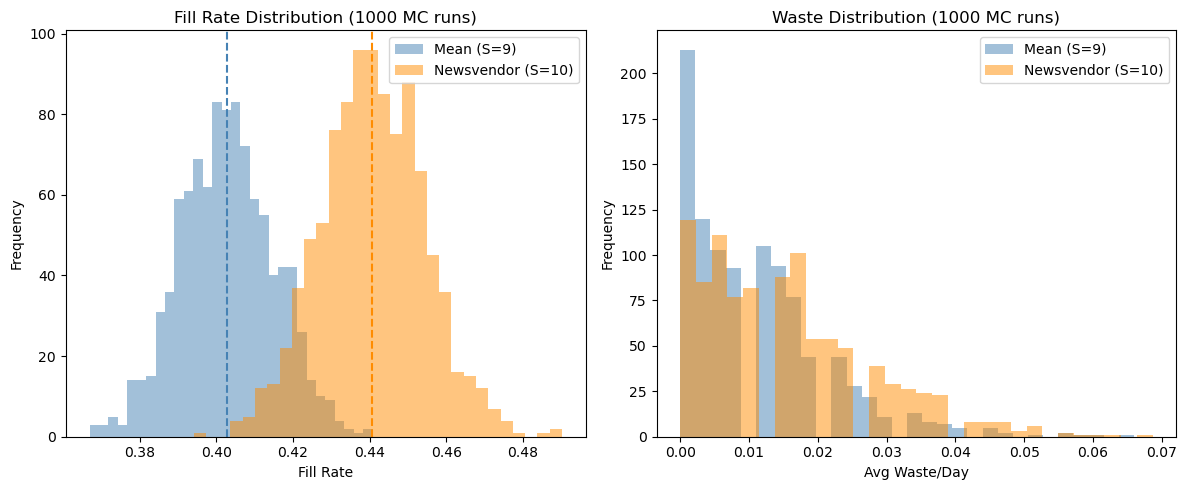

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(res_mean["fill_rate"], bins=30, alpha=0.5, label=f"Mean (S={S_mean})", color="steelblue")
axes[0].hist(res_nv["fill_rate"], bins=30, alpha=0.5, label=f"Newsvendor (S={S_nv})", color="darkorange")
axes[0].axvline(res_mean["fill_rate"].mean(), color="steelblue", linestyle="--")
axes[0].axvline(res_nv["fill_rate"].mean(), color="darkorange", linestyle="--")
axes[0].set_xlabel("Fill Rate"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Fill Rate Distribution (1000 MC runs)"); axes[0].legend()

axes[1].hist(res_mean["avg_waste_per_day"], bins=30, alpha=0.5, label=f"Mean (S={S_mean})", color="steelblue")
axes[1].hist(res_nv["avg_waste_per_day"], bins=30, alpha=0.5, label=f"Newsvendor (S={S_nv})", color="darkorange")
axes[1].set_xlabel("Avg Waste/Day"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Waste Distribution (1000 MC runs)"); axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "baseline_fill_rate_comparison.png"), dpi=150)
plt.show()